# Résolution de F(x)=0

In [570]:
import sympy as sp
import scipy as sc
import numpy as np
from time import sleep,time
import matplotlib.pyplot as plt

## Un exemple en dimension 1

On s'intéresse ici au calcul de la racine carré de $2$.
Pour cela, on va résoudre l'équation
$$ x^2-2 =0$$
c'est-à-dire que $F(x)=x^2-2$.

In [571]:
F = lambda x : x**2-2

- ### Application de la méthode du point fixe

On définit $G_\omega$. On va en fait gérer $\omega$ comme une variable, car on lui donnera différentes valeurs par la suite.

In [572]:
G = lambda x,omega : x + omega * F(x)

On sait qu'un bon choix est $\omega \simeq -1/F'(x^*)$, où $x^*=\sqrt{2}$ est une solution du problème, et $x^{(0)} \simeq x^*$.
On peut par exemple prendre $x^{(0)}=1.5$ et $\omega \simeq -1/F'(x^{(0)})$, mais on peut aussi fixer $\omega$ indépendamment du choix de $x^{(0)}$.

In [573]:
t = sp.symbols('t')
dF_dt = sp.diff(F(t),t)

x0 = 1.5
omega = -1/dF_dt.subs({t:x0})
epsilon = 1e-12

# Test de la méthode de point fixe F(x) < epsilon
x = x0
cpt = 0
while abs(F(x)) > epsilon : 
    x = G(x,omega)
    cpt += 1
print(f'x={x} \nitérations={cpt} \nerreur={abs(x-np.sqrt(2))}\n')

x=1.41421356237337 
itérations=9 
erreur=2.76445533131664E-13



In [574]:
# Test de la méthode de point fixe |x_courant - x_maj| < epsilon
x_courant = x0
x_maj = G(x_courant,omega)
distance = 1
cpt = 0
while distance > epsilon : 
    x_maj = G(x_courant,omega)
    distance = abs(x_courant - x_maj)
    x_courant = x_maj
    cpt += 1
print(f'x={x_maj} \nitérations={cpt} \nerreur={abs(x_maj-np.sqrt(2))}\n')


#Test |F(x)| + |x - x*| < epsilon
x_courant = x0
x_maj = G(x_courant,omega)
distance = 1
cpt = 0
while abs(F(x_maj)) + abs(distance) > epsilon : 
    x_maj = G(x_courant,omega)
    distance = abs(x_courant - x_maj)
    x_courant = x_maj
    cpt += 1
print(f'x={x_maj} \nitérations={cpt} \nerreur={abs(x_maj-np.sqrt(2))}\n')

x=1.41421356237311 
itérations=10 
erreur=1.57651669496772E-14

x=1.41421356237311 
itérations=10 
erreur=1.57651669496772E-14



Tester plusieurs valeurs pour $\omega$, $x^{(0)}$, la précision $\varepsilon$.

Text(0.5, 0, 'epsilon')

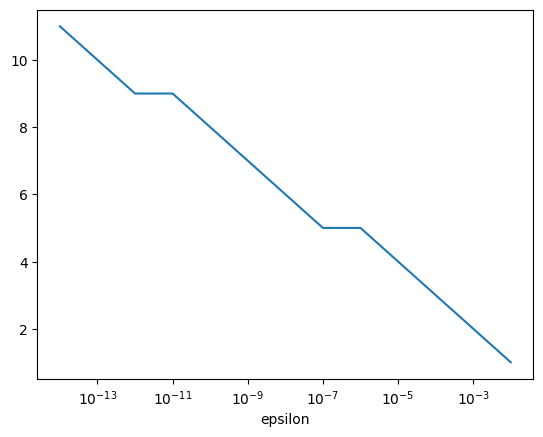

In [575]:
def pt_fixe(omega, x0, epsilon):
    x = x0
    cpt = 0
    while abs(F(x)) > epsilon : 
        x = G(x,omega)
        cpt += 1
    return [x,cpt]

# Tracer en echelle semi-log nombre itérations en fonction de la précision (cpt=fonction(log(epsilon)))

epsilons = [10**(-i) for i in range(2,15)]
iterations = []
for epsilon in epsilons:
    iterations.append(pt_fixe(omega,x0,epsilon)[1])

plt.semilogx(epsilons,iterations)
plt.xlabel('epsilon')

# plt.plot(epsilons,iterations)
# plt.xscale('log')
# plt.xlabel('epsilon')
# plt.ylabel('nombre d\'itérations')



Text(0.5, 0, 'epsilon')

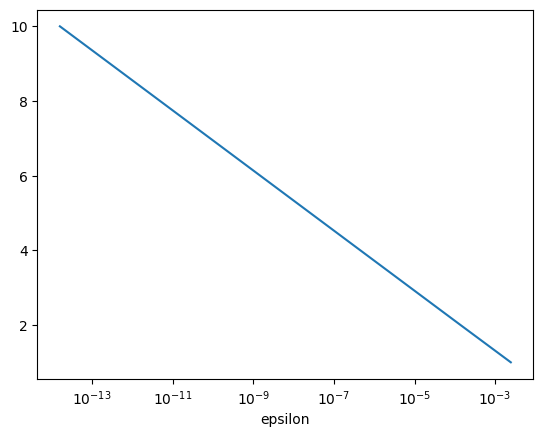

In [576]:
def pt_fixe(omega, x0, iteration):
    x = x0
    cpt = 0
    for i in range(iteration): 
        x = G(x,omega)
        cpt += 1
    return [x,abs(x-np.sqrt(2))]

epsilons = []
iterations = range(1,11)
for i in iterations:
    epsilons.append(pt_fixe(omega,x0,i)[1])
    
plt.semilogx(epsilons,iterations)
plt.xlabel('epsilon')



In [577]:
X_MAX = 10**3

def pt_fixe(omega, x0, epsilon):
    x = x0
    cpt = 0
    while abs(F(x)) > epsilon and abs(x) < X_MAX: 
        x = G(x,omega)
        cpt += 1
    return [x,cpt]

tab_xo = [1.4, 1.5, 1.6, 2.1, 3.0]
tab_omega = [-1/dF_dt.subs({t:x0_i}) for x0_i in tab_xo]
tab_precision = [10**(-i) for i in range(2,12)]

for x0 in tab_xo:
    for omega in tab_omega:
        for epsilon in tab_precision:
            [x,cpt] = pt_fixe(omega,x0,epsilon)
            print(f'omega={omega} x0={x0} precision={epsilon}, \nx={x} cpt={cpt} erreur={abs(x-np.sqrt(2))}\n')




omega=-0.357142857142857 x0=1.4 precision=0.01, 
x=1.41428571428571 cpt=1 erreur=0.0000721519126192227

omega=-0.357142857142857 x0=1.4 precision=0.001, 
x=1.41428571428571 cpt=1 erreur=0.0000721519126192227

omega=-0.357142857142857 x0=1.4 precision=0.0001, 
x=1.41421282798834 cpt=2 erreur=7.34384757006268E-7

omega=-0.357142857142857 x0=1.4 precision=1e-05, 
x=1.41421282798834 cpt=2 erreur=7.34384757006268E-7

omega=-0.357142857142857 x0=1.4 precision=1e-06, 
x=1.41421356982878 cpt=3 erreur=7.45568118354356E-9

omega=-0.357142857142857 x0=1.4 precision=1e-07, 
x=1.41421356982878 cpt=3 erreur=7.45568118354356E-9

omega=-0.357142857142857 x0=1.4 precision=1e-08, 
x=1.41421356229740 cpt=4 erreur=7.56941176405235E-11

omega=-0.357142857142857 x0=1.4 precision=1e-09, 
x=1.41421356229740 cpt=4 erreur=7.56941176405235E-11

omega=-0.357142857142857 x0=1.4 precision=1e-10, 
x=1.41421356237386 cpt=5 erreur=7.68274333040608E-13

omega=-0.357142857142857 x0=1.4 precision=1e-11, 
x=1.414213562373

- ### Application de la méthode de Newton

Dans un premier temps, reprendre la démarche précédente, en testant cette fois-ci en fonction du point de départ $x^{(0)}$ et de la précision choisie.

In [578]:
x = 1.5
epsilon = 1e-14
cpt = 0

while abs(F(x)) > epsilon :
    x = x - F(x)/dF_dt.subs({t:x})
    cpt += 1
print(f'x={x} \nerreur={abs(x-np.sqrt(2))} \nitérations={cpt}\n')



x=1.41421356237310 
erreur=0 
itérations=4



In [579]:
def newton(x0, eps):
    x = x0
    cpt = 0 
    while abs(F(x)) > eps :
        x = x - F(x)/dF_dt.subs({t:x})
        cpt += 1 
    return [x,cpt]

[x,cpt] = newton(1.5, 1e-14)
print(f'x={x} \nerreur={abs(x-np.sqrt(2))} \nitérations={cpt}\n')

x=1.41421356237310 
erreur=0 
itérations=4



Dans un deuxième temps, on utilise, plutôt que la dérivée exacte de $F$, la formule des différences finies :
$$ F'(x) \simeq \frac{F(x+\delta)-F(x-\delta)}{2\delta} $$
où $\delta$ est choisi "petit". En général on impose que $\delta < 0.01 \varepsilon$, où $\varepsilon$ est la précision recherchée. Comparer les résultats.

In [580]:
x = x0
epsilon = 1e-12
cpt = 0

delta = 0.001 * epsilon
F_prime = (F(x+delta) - F(x-delta)) / (2*delta)

while abs(F(x)) > epsilon :
    x = x - F(x)/F_prime
    cpt += 1
print(f'x={x} \nerreur={abs(x-np.sqrt(2))} \nitérations={cpt}\n')

x=1.4142135623734249 
erreur=3.297362383136715e-13 
itérations=37



## Un exemple en dimension 3

On s'intéresse ici au calcul d'un vecteur $(x,y,z)$ solution de $F(x,y,z)=(0,0,0)$ où

$$
F(x,y,z) = \begin{pmatrix}
\frac{-89.5 x - \sqrt{\lvert x \rvert +1} -10 y + 14 z +1}{54.5} \\
\frac{-10 x - 80.5 y - \frac{1}{2}\sin(y) + 4z}{54.5} \\
\frac{14 x + 4y - 92.5 z - \arctan(z/2)}{54.5} \\
\end{pmatrix}
$$

In [581]:
def F(X):
    a,b,c=X
    t1=-89.5*a-sp.sqrt(abs(a)+1)-10*b+14*c+1
    #t1=-35*a-sqrt(abs(a)+1)-10*b+14*a+1 ## erreur qui donne Xu meilleur ! 
    t2=-10*a-80.5*b-sp.sin(b)/2+4*c
    t3=14*a+4*b-92.5*c-sp.atan(c/2)
    return sp.Matrix([[t1,t2,t3]]).T/54.5

print('F(1,1,1)=',F(sp.Matrix([1,1,1])))

F(1,1,1)= Matrix([[-1.55045871559633 - 0.018348623853211*sqrt(2)], [-1.58715596330275 - 0.00917431192660551*sin(1)], [-1.36697247706422 - 0.018348623853211*atan(1/2)]])


On calcule la matrice jacobienne de $F$.

In [582]:
x,y,z = sp.symbols('x y z', real=True)
dF_dx = sp.diff(F([x,y,z]),x)
dF_dy = sp.diff(F([x,y,z]),y)
dF_dz = sp.diff(F([x,y,z]),z)
JF = sp.Matrix([dF_dx.T,dF_dy.T,dF_dz.T])
JF

Matrix([
[-1.64220183486239 - 0.00917431192660551*sign(x)/sqrt(Abs(x) + 1),                              -0.18348623853211,                                    0.256880733944954],
[                                               -0.18348623853211, -0.00917431192660551*cos(y) - 1.47706422018349,                                    0.073394495412844],
[                                               0.256880733944954,                              0.073394495412844, -1.69724770642202 - 0.00917431192660551/(z**2/4 + 1)]])

Comme on n'a aucun idée de la solution, on partira de $x^{(0)}=(0,0,0)$ ou de $x^{(0)}=(0.5,0.5,0.5)$.

- ### Application de la méthode du point fixe

Pour la matrice $\omega$, on pourra prendre par exemple $\omega = - DF(x^{(0)})^{-1}$, où $DF(x^{(0)})$ est la Jacobienne de F au point $x^0$.

In [583]:
# Application de la méthode de point fixe à F(X) = 0
x0 = sp.Matrix([0,0,0])
# x0 = sp.Matrix([0.5,0.5,0.5])
F_x0 = F(x0)

JF.subs({x:x0[0],y:x0[1],z:x0[2]}).inv()



def pt_fixe_3d(omega, x0, epsilon):
    x = x0
    cpt = 0 
    while abs(F(x)).norm() > epsilon :
        x = x + omega * F(x)
        cpt += 1
    return [x,cpt]


omega = -JF.subs({x:x0[0],y:x0[1],z:x0[2]}).inv()

epsilon = 1e-6
[x,cpt] = pt_fixe_3d(omega,x0,epsilon) 
print(f'x={x} \nerreur={abs(x-sp.Matrix([1,1,1])).norm()} \nitérations={cpt}\n')




x=Matrix([[0], [0], [0]]) 
erreur=sqrt(3) 
itérations=0



- ### Application de la méthode de Newton

Pour le calcul de $y=DF(X)^{-1}.F(X)$, on utilise la fonction de résolution de système linéaire LUsolve(), car ce vecteur $y$ est en fait solution du système $DF(X).y=F(X)$. Ainsi $y$ est donné par
$$
y \;\leftarrow\; \text{DF(X).LUsolve(F(X))}
$$

## Inversion de matrice par la méthode de Newton

Soit $A$ une matrice inversible $d \times d$, alors la méthode de Newton appliquée au calcul d'une solution de l'équation
$$ X^{-1} -A = 0$$
est donnée par la récurrence
$$
\forall n \geq 0, \quad X^{n+1} = 2 X^n (I_d - A X^n) 
$$
où $I_d$ est la matrice de dimension $d$
<i>(attention aux notations : ici $X^{-1}$ est l'inverse de la matrice $X$, et dans la suite du paragraphe la notation $X^n$ désigne le $n$-ième terme de la suite générée par la méthode de Newton, pour $n \geq 0$)</i>.
En effet, si on définit $F : X \mapsto  X^{-1} -A$ alors on peut montrer que
$$ DF(X).H = - X^{-1} H X^{-1} $$
pour toute matrice $H$ de dimensiosn $d \times d$.
On en déduit
$$ DF(X)^{-1}.H = - X H X$$
On remarque que la méthode de Newton ne nécessite pas de calculer l'inverse !

In [584]:
A = sp.Matrix([[1,2,3],[3,2,1],[1,1,2]])
A.det() # déterminant de A

-4

Comme le point initial pour Newton doit être proche de la solution, on choisira une perturbation aléatoire de la solution, calculée à partir des deux matrices suivantes.

In [585]:
from numpy.random import rand

B=A.inv()
R=sp.Matrix(rand(3,3))

Comme critère d'arrêt, on choisit $\lVert XA - I_d \rVert < \varepsilon$, ce qui mesure le fait que $X$ est bien l'inverse de $A$.